# Importing Libraries

In [1]:
import os 
import pandas as pd

# Load and setup the dataset

In [9]:
base =  pd.read_csv("results_baseline.csv")
base.head()

,image_path,image_id,species,common_name,kingdom,phylum,class,order,family,genus,score,top_no,topk_predictions_json
0,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Thomomys Plesiothomomys potomacensis,NaN,Animalia,Chordata,Mammalia,Rodentia,Geomyidae,Thomomys,0.444254,1,"[{""species"": ""Thomomys Plesiothomomys potomace..."
1,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Thomomys Plesiothomomys potomacensis,NaN,Animalia,Chordata,Mammalia,Rodentia,Geomyidae,Thomomys,0.444246,2,"[{""species"": ""Thomomys Plesiothomomys potomace..."
2,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Thomomys Plesiothomomys potomacensis,NaN,Animalia,Chordata,Mammalia,Rodentia,Geomyidae,Thomomys,0.444246,3,"[{""species"": ""Thomomys Plesiothomomys potomace..."
3,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Gillichthys mirabilis,Longjaw mudsucker,Animalia,Chordata,NaN,Perciformes,Gobiidae,Gillichthys,0.089155,4,"[{""species"": ""Thomomys Plesiothomomys potomace..."
4,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Gillichthys mirabilis,Longjaw mudsucker,Animalia,Chordata,NaN,Perciformes,Gobiidae,Gillichthys,0.089155,5,"[{""species"": ""Thomomys Plesiothomomys potomace..."


In [ ]:
base.rename(columns={
    "kingdom": "model_kingdom",
    "phylum": "model_phylum",
    "class": "model_class",
    "order": "model_order",
    "family": "model_family",
    "genus": "model_genus",
    }, inplace=True)


In [11]:
base.columns

Index(['image_path', 'image_id', 'species', 'common_name', 'model_kingdom',
       'model_phylum', 'model_class', 'model_order', 'model_family',
       'model_genus', 'score', 'top_no', 'topk_predictions_json'],
      dtype='str')

In [3]:
main = pd.read_csv("../EDA/Dataset.csv")
main.head()

,observation_id,photo_id,image_id,license_code,square_url,medium_url,large_url,original_url,scientific_name,common_name,...,uri,pred_prey,special_type_of_feeding,taxon_kingdom,taxon_phylum,taxon_class,taxon_order,taxon_family,taxon_genus,taxon_species
0,341194952,621071156,obs_341194952_photo_621071156,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba
1,341194952,621071168,obs_341194952_photo_621071168,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba
2,341194952,621071177,obs_341194952_photo_621071177,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba
3,341194952,621071190,obs_341194952_photo_621071190,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba
4,341194952,621071213,obs_341194952_photo_621071213,cc-by,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,https://inaturalist-open-data.s3.amazonaws.com...,Ardea alba,Great Egret,...,https://www.inaturalist.org/observations/34119...,Pred,Predation,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea,Ardea alba


In [14]:

base = base.merge(
    main[["image_id", "scientific_name", "taxon_kingdom", "taxon_phylum", "taxon_class", "taxon_order", "taxon_family", "taxon_genus"]],
    on="image_id",
    how="left"
)

base.rename(columns={
    "scientific_name": "User_classified",
    "taxon_kingdom": "user_kingdom",
    "taxon_phylum": "user_phylum",
    "taxon_class": "user_class",
    "taxon_order": "user_order",
    "taxon_family": "user_family",
    "taxon_genus": "user_genus"
    }, inplace=True)

base[["User_classified", "species", "user_kingdom", "model_kingdom", "user_phylum", "model_phylum", "user_class", "model_class", "user_order", "model_order", "user_family", "model_family", "user_genus", "model_genus"]]


,User_classified,species,user_kingdom,model_kingdom,user_phylum,model_phylum,user_class,model_class,user_order,model_order,user_family,model_family,user_genus,model_genus
0,Ardea alba,Thomomys Plesiothomomys potomacensis,Animalia,Animalia,Chordata,Chordata,Aves,Mammalia,Pelecaniformes,Rodentia,Ardeidae,Geomyidae,Ardea,Thomomys
1,Ardea alba,Thomomys Plesiothomomys potomacensis,Animalia,Animalia,Chordata,Chordata,Aves,Mammalia,Pelecaniformes,Rodentia,Ardeidae,Geomyidae,Ardea,Thomomys
2,Ardea alba,Thomomys Plesiothomomys potomacensis,Animalia,Animalia,Chordata,Chordata,Aves,Mammalia,Pelecaniformes,Rodentia,Ardeidae,Geomyidae,Ardea,Thomomys
3,Ardea alba,Gillichthys mirabilis,Animalia,Animalia,Chordata,Chordata,Aves,NaN,Pelecaniformes,Perciformes,Ardeidae,Gobiidae,Ardea,Gillichthys
4,Ardea alba,Gillichthys mirabilis,Animalia,Animalia,Chordata,Chordata,Aves,NaN,Pelecaniformes,Perciformes,Ardeidae,Gobiidae,Ardea,Gillichthys
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124030,Geococcyx californianus,Geococcyx californianus,Animalia,Animalia,Chordata,Chordata,Aves,Aves,Cuculiformes,Cuculiformes,Cuculidae,Cuculidae,Geococcyx,Geococcyx
124031,Geococcyx californianus,Geococcyx velox,Animalia,Animalia,Chordata,Chordata,Aves,Aves,Cuculiformes,Cuculiformes,Cuculidae,Cuculidae,Geococcyx,Geococcyx
124032,Geococcyx californianus,Campylorhynchus brunneicapillus,Animalia,Animalia,Chordata,Chordata,Aves,Aves,Cuculiformes,Passeriformes,Cuculidae,Troglodytidae,Geococcyx,Campylorhynchus
124033,Geococcyx californianus,Ortygornis sephaena,Animalia,Animalia,Chordata,Chordata,Aves,Aves,Cuculiformes,Galliformes,Cuculidae,Phasianidae,Geococcyx,Ortygornis


In [ ]:
base.rename(columns={"scientific_name": "User_classified"}, inplace=True)

In [25]:
base["same_species?"] = base["User_classified"] == base["species"]
base[["User_classified", "species", "same_species?"]]

,User_classified,species,same_species?
0,Ardea alba,Thomomys Plesiothomomys potomacensis,False
1,Ardea alba,Thomomys Plesiothomomys potomacensis,False
2,Ardea alba,Thomomys Plesiothomomys potomacensis,False
3,Ardea alba,Gillichthys mirabilis,False
4,Ardea alba,Gillichthys mirabilis,False
...,...,...,...
124030,Geococcyx californianus,Geococcyx californianus,True
124031,Geococcyx californianus,Geococcyx velox,False
124032,Geococcyx californianus,Campylorhynchus brunneicapillus,False
124033,Geococcyx californianus,Ortygornis sephaena,False


In [ ]:
base["same_kingdom?"] = base["model_kingdom"] == base["user_kingdom"]
# base[["user_kingdom", "same_kingdom?"]]

,user_kingdom,same_kingdom?
0,Animalia,True
1,Animalia,True
2,Animalia,True
3,Animalia,True
4,Animalia,True
...,...,...
124030,Animalia,True
124031,Animalia,True
124032,Animalia,True
124033,Animalia,True


In [16]:
base["same_phylum?"] = base["model_phylum"] == base["user_phylum"]
base["same_class?"] = base["model_class"] == base["user_class"]
base["same_order?"] = base["model_order"] == base["user_order"]
base["same_family?"] = base["model_family"] == base["user_family"]
base["same_genus?"] = base["model_genus"] == base["user_genus"]

In [26]:
base.columns

Index(['image_path', 'image_id', 'species', 'common_name', 'model_kingdom',
       'model_phylum', 'model_class', 'model_order', 'model_family',
       'model_genus', 'score', 'top_no', 'topk_predictions_json',
       'User_classified', 'user_kingdom', 'user_phylum', 'user_class',
       'user_order', 'user_family', 'user_genus', 'same_kingdom?',
       'same_phylum?', 'same_class?', 'same_order?', 'same_family?',
       'same_genus?', 'same_species?'],
      dtype='str')

In [27]:
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 124035 entries, 0 to 124034
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   image_path             124035 non-null  str    
 1   image_id               124035 non-null  str    
 2   species                124035 non-null  str    
 3   common_name            78330 non-null   str    
 4   model_kingdom          124035 non-null  str    
 5   model_phylum           123998 non-null  str    
 6   model_class            117428 non-null  str    
 7   model_order            116575 non-null  str    
 8   model_family           123628 non-null  str    
 9   model_genus            124035 non-null  str    
 10  score                  124035 non-null  float64
 11  top_no                 124035 non-null  int64  
 12  topk_predictions_json  124035 non-null  str    
 13  User_classified        124035 non-null  str    
 14  user_kingdom           124035 non-null  str    

In [28]:
base.isna().sum()

image_path                   0
image_id                     0
species                      0
common_name              45705
model_kingdom                0
model_phylum                37
model_class               6607
model_order               7460
model_family               407
model_genus                  0
score                        0
top_no                       0
topk_predictions_json        0
User_classified              0
user_kingdom                 0
user_phylum                  0
user_class                   0
user_order                   0
user_family                  0
user_genus                   0
same_kingdom?                0
same_phylum?                 0
same_class?                  0
same_order?                  0
same_family?                 0
same_genus?                  0
same_species?                0
dtype: int64

In [33]:
base.to_csv("baseline.csv", index=False)

# Helper Functions

In [21]:
def find_ids(same,df):
    return df[df[same]== True]["image_id"].unique()
    


In [22]:
def category_accuracy(df_eval, category_match_col, category_col):
    print(f"{category_col} categories correctly identified:")
    true_count= df_eval[df_eval[category_match_col] == True].groupby(category_col)["image_id"].count()
    false_count= df_eval[df_eval[category_match_col] == False].groupby(category_col)["image_id"].count()
    total_count= df_eval.groupby(category_col)["image_id"].count()

    result = pd.DataFrame({
        "success_count": true_count,
        "failure_count": false_count,
        "total_count": total_count
    }).fillna(0)

    result["pct_success"] = ((result["success_count"] / result["total_count"]) * 100).round(2)
    result["pct_failure"] = ((result["failure_count"] / result["total_count"]) * 100).round(2)
    
    return result

# EDA

In [29]:
base_eval = pd.DataFrame({
    "image_id": base["image_id"].unique()
})

base_eval

,image_id
0,obs_341194952_photo_621071156
1,obs_341194952_photo_621071168
2,obs_341194952_photo_621071177
3,obs_341194952_photo_621071190
4,obs_341194952_photo_621071213
...,...
24802,obs_414645_photo_28352912
24803,obs_338604_photo_421440
24804,obs_338604_photo_421441
24805,obs_338604_photo_421442


In [30]:
base_eval["species_match"]= base_eval["image_id"].isin(find_ids("same_species?", base))
base_eval[base_eval["species_match"]==False]

,image_id,species_match
0,obs_341194952_photo_621071156,False
8,obs_341060278_photo_547585371,False
10,obs_341060278_photo_547585471,False
11,obs_341060248_photo_547586114,False
12,obs_341011035_photo_620687628,False
...,...,...
24797,obs_424251_photo_534568,False
24798,obs_424251_photo_534567,False
24800,obs_414707_photo_521820,False
24801,obs_414645_photo_521779,False


In [31]:
base_eval["kingdom_match"]= base_eval["image_id"].isin(find_ids("same_kingdom?", base))
base_eval["phylum_match"]= base_eval["image_id"].isin(find_ids("same_phylum?", base))
base_eval["class_match"]= base_eval["image_id"].isin(find_ids("same_class?", base))
base_eval["order_match"]= base_eval["image_id"].isin(find_ids("same_order?", base))
base_eval["family_match"]= base_eval["image_id"].isin(find_ids("same_family?", base))
base_eval["genus_match"]= base_eval["image_id"].isin(find_ids("same_genus?", base))
# df_eval[df_eval["kingdom_match"]==False]
base_eval

,image_id,species_match,kingdom_match,phylum_match,class_match,order_match,family_match,genus_match
0,obs_341194952_photo_621071156,False,True,True,False,False,False,False
1,obs_341194952_photo_621071168,True,True,True,True,True,True,True
2,obs_341194952_photo_621071177,True,True,True,True,True,True,True
3,obs_341194952_photo_621071190,True,True,True,True,True,True,True
4,obs_341194952_photo_621071213,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...
24802,obs_414645_photo_28352912,False,False,False,False,False,False,False
24803,obs_338604_photo_421440,True,True,True,True,True,True,True
24804,obs_338604_photo_421441,True,True,True,True,True,True,True
24805,obs_338604_photo_421442,True,True,True,True,True,True,True


# Distribution of hierachical match

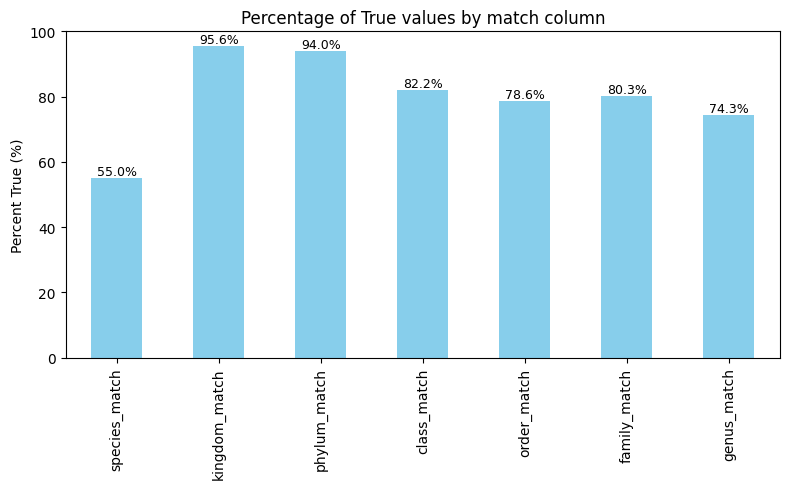

In [32]:
# Calculate percentage true per match column and plot
match_cols = [c for c in base_eval.columns if c.endswith("_match")]
percent_true = base_eval[match_cols].mean() * 100

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
percent_true.plot(kind="bar", ax=ax, color="skyblue")
ax.set_ylabel("Percent True (%)")
ax.set_title("Percentage of True values by match column")
ax.set_ylim(0, 100)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()